# Lecture 04-1: Linear Regression

**Machine Learning Applications in Physics (PHYG004)** — Sogang University, 2026 Spring

---

## Learning Objectives

1. Define the linear regression model $\hat{y} = Xw + b$ and implement it in JAX
2. Derive and implement the MSE loss function
3. Solve linear regression analytically via the normal equation
4. Implement full-batch and minibatch SGD from scratch using `jax.grad`
5. Use Optax optimizers (SGD, Adam) for cleaner training loops
6. Understand weight decay (L2 regularization) and its effect on overfitting

In [1]:
# Install dependencies (run on Google Colab)
!pip install -q jax jaxlib optax flax matplotlib

In [2]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")

key = jax.random.PRNGKey(42)

JAX version: 0.9.1
Backend: cpu


---
## 1. Linear Regression Model

The linear regression model predicts:

$$\hat{y} = Xw + b$$

where $X \in \mathbb{R}^{n \times d}$ is the input matrix ($n$ samples, $d$ features), $w \in \mathbb{R}^d$ is the weight vector, and $b \in \mathbb{R}$ is the bias.

Equivalently, we can absorb the bias into the weights by augmenting $X$ with a column of ones:

$$\hat{y} = \tilde{X}\tilde{w}, \qquad \tilde{X} = [X \mid \mathbf{1}], \quad \tilde{w} = \begin{pmatrix} w \\ b \end{pmatrix}$$

In [3]:
def linear_model(params: dict, X: jnp.ndarray) -> jnp.ndarray:
    """Linear regression: y_hat = X @ w + b."""
    return X @ params['w'] + params['b']

# Quick test
test_params = {'w': jnp.array([1.0, 2.0]), 'b': jnp.array(0.5)}
test_X = jnp.ones((3, 2))
y_hat = linear_model(test_params, test_X)
print(f"X shape: {test_X.shape}")
print(f"w shape: {test_params['w'].shape}")
print(f"y_hat shape: {y_hat.shape}")
print(f"y_hat = {y_hat}")

X shape: (3, 2)
w shape: (2,)
y_hat shape: (3,)
y_hat = [3.5 3.5 3.5]


---
## 2. Synthetic Data Generation

We generate data from a known linear model with additive Gaussian noise:

$$y = Xw_{\text{true}} + b_{\text{true}} + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

W0313 00:10:44.852829 42279228 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


X shape: (1000, 2)
y shape: (1000,)
True weights: w = [ 2.  -3.4], b = 4.2
Noise std: 0.5


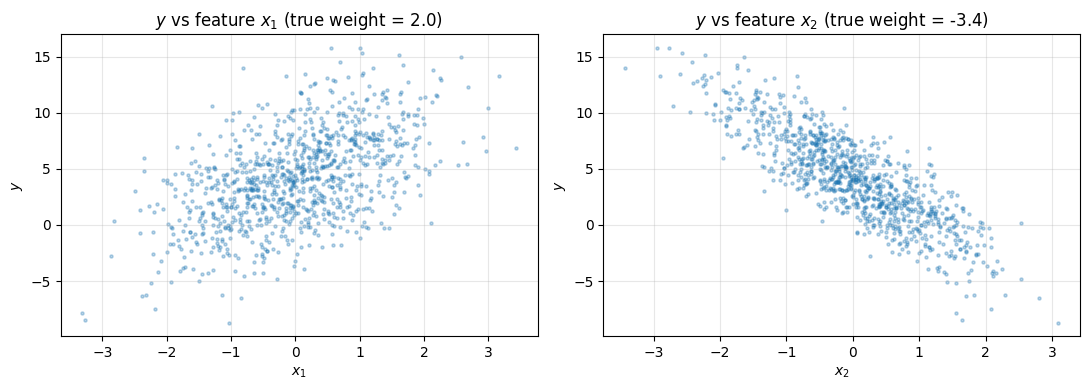

In [4]:
# True parameters
w_true = jnp.array([2.0, -3.4])
b_true = 4.2
n_samples = 1000
n_features = 2
noise_std = 0.5

# Generate data
key, k1, k2 = jax.random.split(key, 3)
X = jax.random.normal(k1, (n_samples, n_features))
noise = noise_std * jax.random.normal(k2, (n_samples,))
y = X @ w_true + b_true + noise

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"True weights: w = {w_true}, b = {b_true}")
print(f"Noise std: {noise_std}")

# Visualize: scatter plot of y vs each feature
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, ax in enumerate(axes):
    ax.scatter(X[:, i], y, s=5, alpha=0.3)
    ax.set_xlabel(f'$x_{i+1}$')
    ax.set_ylabel('$y$')
    ax.set_title(f'$y$ vs feature $x_{i+1}$ (true weight = {w_true[i]:.1f})')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Loss Function: Mean Squared Error

The MSE loss measures the average squared prediction error:

$$\mathcal{L}(w, b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2 = \frac{1}{n}\|Xw + b - y\|^2$$

**Connection to maximum likelihood**: If $y_i = x_i^\top w + b + \epsilon_i$ with $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, then minimizing MSE is equivalent to maximizing the log-likelihood:

$$\log p(y \mid X, w, b) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_i (y_i - x_i^\top w - b)^2$$

In [5]:
def mse_loss(params: dict, X: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
    """Mean squared error loss."""
    y_hat = linear_model(params, X)
    return jnp.mean((y_hat - y) ** 2)

# Test with random params
init_params = {'w': jnp.zeros(n_features), 'b': jnp.array(0.0)}
loss_val = mse_loss(init_params, X, y)
print(f"Loss with zero params: {loss_val:.4f}")
print(f"(Should be close to Var(y) = {jnp.var(y):.4f})")

Loss with zero params: 33.8393
(Should be close to Var(y) = 16.2226)


---
## 4. Analytic (Closed-Form) Solution

Setting $\nabla_w \mathcal{L} = 0$ gives the **normal equation**:

$$\tilde{w}^* = (\tilde{X}^\top \tilde{X})^{-1} \tilde{X}^\top y$$

where $\tilde{X} = [X \mid \mathbf{1}]$ includes the bias column.

In practice, we use `jnp.linalg.solve` instead of computing the inverse directly (more numerically stable).

In [6]:
# Augment X with a column of ones for the bias
X_aug = jnp.concatenate([X, jnp.ones((n_samples, 1))], axis=1)
print(f"X_aug shape: {X_aug.shape}")

# Solve normal equation: (X^T X) w = X^T y
# Using jnp.linalg.solve instead of explicit inverse
w_analytic = jnp.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)

w_solved = w_analytic[:n_features]
b_solved = w_analytic[n_features]

print(f"\nAnalytic solution:")
print(f"  w = {w_solved}")
print(f"  b = {b_solved:.4f}")
print(f"\nTrue parameters:")
print(f"  w = {w_true}")
print(f"  b = {b_true}")
print(f"\nRecovery error:")
print(f"  |w - w_true| = {jnp.linalg.norm(w_solved - w_true):.6f}")
print(f"  |b - b_true| = {abs(b_solved - b_true):.6f}")

# Compute loss at analytic solution
analytic_params = {'w': w_solved, 'b': b_solved}
analytic_loss = mse_loss(analytic_params, X, y)
print(f"\nMSE at analytic solution: {analytic_loss:.6f}")
print(f"(Should be close to noise variance = {noise_std**2:.4f})")

X_aug shape: (1000, 3)

Analytic solution:
  w = [ 1.9799434 -3.398056 ]
  b = 4.1948

True parameters:
  w = [ 2.  -3.4]
  b = 4.2

Recovery error:
  |w - w_true| = 0.020151
  |b - b_true| = 0.005150

MSE at analytic solution: 0.240824
(Should be close to noise variance = 0.2500)


---
## 5. SGD from Scratch

Gradient descent updates parameters iteratively:

$$w \leftarrow w - \eta \nabla_w \mathcal{L}, \qquad b \leftarrow b - \eta \nabla_b \mathcal{L}$$

We use `jax.grad` to compute gradients automatically. Start with **full-batch** gradient descent (using all data at every step).

Learned: w = [ 1.979945  -3.3980544], b = 4.1948
True:    w = [ 2.  -3.4], b = 4.2
Final loss: 0.240824
Analytic loss: 0.240824


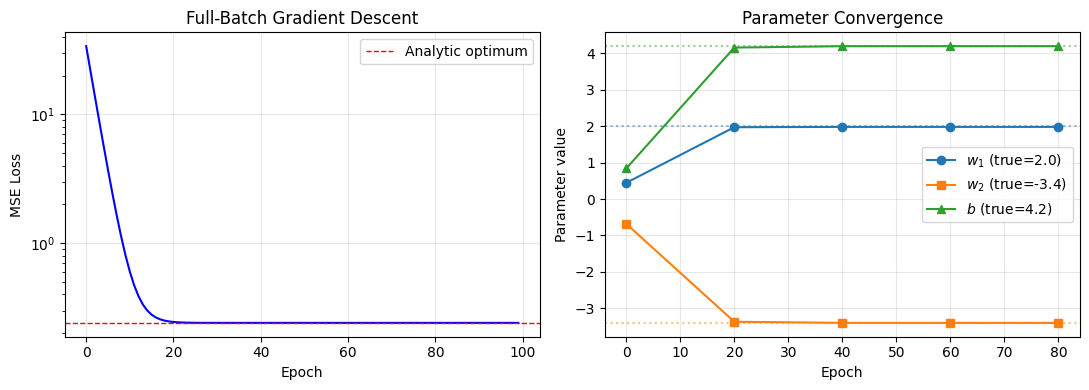

In [7]:
grad_fn = jax.grad(mse_loss)

# Initialize parameters at zero
params = {'w': jnp.zeros(n_features), 'b': jnp.array(0.0)}
lr = 0.1
n_epochs = 100

losses_gd = []
params_history = []

for epoch in range(n_epochs):
    loss = mse_loss(params, X, y)
    losses_gd.append(float(loss))
    grads = grad_fn(params, X, y)
    params = {
        'w': params['w'] - lr * grads['w'],
        'b': params['b'] - lr * grads['b'],
    }
    if epoch % 20 == 0:
        params_history.append((epoch, params['w'].copy(), params['b']))

print(f"Learned: w = {params['w']}, b = {params['b']:.4f}")
print(f"True:    w = {w_true}, b = {b_true}")
print(f"Final loss: {losses_gd[-1]:.6f}")
print(f"Analytic loss: {float(analytic_loss):.6f}")

# Plot loss curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(losses_gd, 'b-', lw=1.5)
axes[0].axhline(float(analytic_loss), color='r', ls='--', lw=1, label='Analytic optimum')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Full-Batch Gradient Descent')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot parameter convergence
epochs_h = [e for e, _, _ in params_history]
w0_h = [float(w[0]) for _, w, _ in params_history]
w1_h = [float(w[1]) for _, w, _ in params_history]
b_h = [float(b) for _, _, b in params_history]

axes[1].plot(epochs_h, w0_h, 'o-', label=f'$w_1$ (true={w_true[0]:.1f})')
axes[1].plot(epochs_h, w1_h, 's-', label=f'$w_2$ (true={w_true[1]:.1f})')
axes[1].plot(epochs_h, b_h, '^-', label=f'$b$ (true={b_true:.1f})')
axes[1].axhline(w_true[0], color='C0', ls=':', alpha=0.5)
axes[1].axhline(w_true[1], color='C1', ls=':', alpha=0.5)
axes[1].axhline(b_true, color='C2', ls=':', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Parameter value')
axes[1].set_title('Parameter Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Minibatch SGD

Full-batch GD uses all $n$ samples to compute each gradient — expensive for large datasets. **Minibatch SGD** samples a random subset of size $B$ at each step:

$$w \leftarrow w - \eta \cdot \frac{1}{B}\sum_{i \in \mathcal{B}} \nabla_w \ell_i$$

Trade-offs:
- Smaller batch $\Rightarrow$ noisier gradient, but cheaper per step
- Larger batch $\Rightarrow$ smoother gradient, but more computation per step
- Noise can help escape local minima (not relevant for convex problems like linear regression, but important for deep learning)

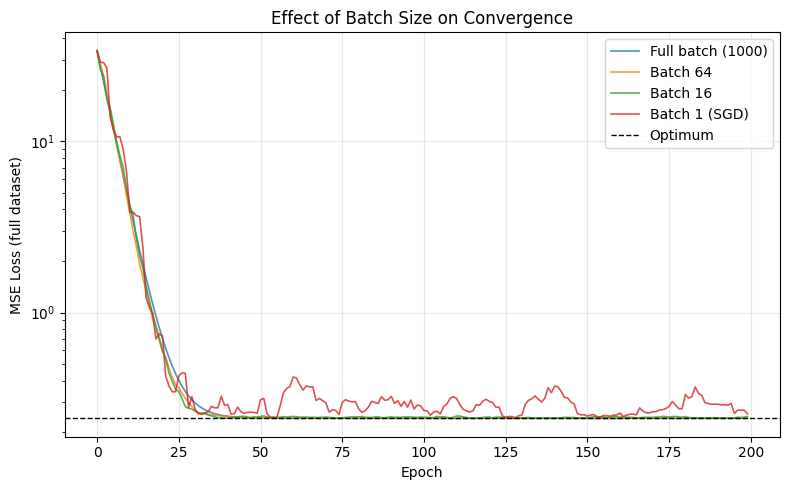

Observations:
  - Full batch: smooth, monotone convergence
  - Batch 64: slightly noisy but converges fast
  - Batch 16: more noise, still converges
  - Batch 1: very noisy (pure SGD), oscillates around optimum


In [8]:
def train_minibatch_sgd(X, y, batch_size, lr, n_epochs, rng_key):
    """Train linear regression with minibatch SGD."""
    params = {'w': jnp.zeros(X.shape[1]), 'b': jnp.array(0.0)}
    grad_fn = jax.grad(mse_loss)
    losses = []
    n = X.shape[0]

    for epoch in range(n_epochs):
        # Record full-dataset loss for fair comparison
        losses.append(float(mse_loss(params, X, y)))

        if batch_size >= n:
            # Full batch
            grads = grad_fn(params, X, y)
        else:
            # Sample minibatch
            rng_key, sk = jax.random.split(rng_key)
            idx = jax.random.choice(sk, n, shape=(batch_size,), replace=False)
            X_batch = X[idx]
            y_batch = y[idx]
            grads = grad_fn(params, X_batch, y_batch)

        params = {
            'w': params['w'] - lr * grads['w'],
            'b': params['b'] - lr * grads['b'],
        }

    return params, losses


# Compare different batch sizes
batch_sizes = [n_samples, 64, 16, 1]
labels = ['Full batch (1000)', 'Batch 64', 'Batch 16', 'Batch 1 (SGD)']
n_epochs = 200

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for bs, label in zip(batch_sizes, labels):
    key, sk = jax.random.split(key)
    _, losses = train_minibatch_sgd(X, y, bs, lr=0.05, n_epochs=n_epochs, rng_key=sk)
    ax.plot(losses, lw=1.2, label=label, alpha=0.8)

ax.axhline(float(analytic_loss), color='k', ls='--', lw=1, label='Optimum')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (full dataset)')
ax.set_title('Effect of Batch Size on Convergence')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("  - Full batch: smooth, monotone convergence")
print("  - Batch 64: slightly noisy but converges fast")
print("  - Batch 16: more noise, still converges")
print("  - Batch 1: very noisy (pure SGD), oscillates around optimum")

---
## 7. Concise Implementation with Optax

Optax provides standard optimizers so you don't have to implement the update rule manually. The pattern:

1. Create optimizer: `tx = optax.sgd(lr)` or `tx = optax.adam(lr)`
2. Initialize state: `opt_state = tx.init(params)`
3. Each step: compute gradients, then `updates, opt_state = tx.update(grads, opt_state, params)` and `params = optax.apply_updates(params, updates)`

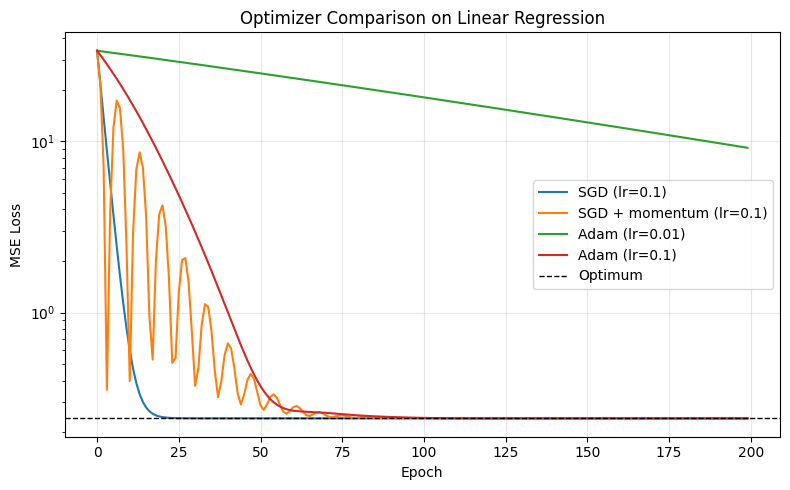

Adam result: w = [ 1.9798925 -3.398103 ], b = 4.1948
True:        w = [ 2.  -3.4], b = 4.2


In [9]:
def train_optax(X, y, optimizer, n_epochs):
    """Train linear regression with an Optax optimizer."""
    params = {'w': jnp.zeros(X.shape[1]), 'b': jnp.array(0.0)}
    opt_state = optimizer.init(params)

    @jax.jit
    def step(params, opt_state):
        loss, grads = jax.value_and_grad(mse_loss)(params, X, y)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss

    losses = []
    for epoch in range(n_epochs):
        params, opt_state, loss = step(params, opt_state)
        losses.append(float(loss))

    return params, losses


# Compare SGD vs Adam
n_epochs = 200

optimizers = {
    'SGD (lr=0.1)': optax.sgd(0.1),
    'SGD + momentum (lr=0.1)': optax.sgd(0.1, momentum=0.9),
    'Adam (lr=0.01)': optax.adam(0.01),
    'Adam (lr=0.1)': optax.adam(0.1),
}

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for name, opt in optimizers.items():
    params_opt, losses_opt = train_optax(X, y, opt, n_epochs)
    ax.plot(losses_opt, lw=1.5, label=name)

ax.axhline(float(analytic_loss), color='k', ls='--', lw=1, label='Optimum')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Optimizer Comparison on Linear Regression')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final parameters for Adam
params_adam, _ = train_optax(X, y, optax.adam(0.1), n_epochs)
print(f"Adam result: w = {params_adam['w']}, b = {params_adam['b']:.4f}")
print(f"True:        w = {w_true}, b = {b_true}")

---
## 8. Weight Decay (L2 Regularization)

When a model has too many parameters relative to the data, it can **overfit** by fitting noise. **Weight decay** adds a penalty on the weight magnitude:

$$\mathcal{L}_{\text{reg}}(w, b) = \frac{1}{n}\|Xw + b - y\|^2 + \lambda \|w\|^2$$

This is equivalent to a Gaussian prior on $w$: $p(w) \propto \exp(-\lambda \|w\|^2)$ (MAP estimation).

**Demo: polynomial regression.** We fit a degree-14 polynomial ($d=14$ parameters) to only 15 noisy data points sampled from $y = \sin(2\pi x)$. Without regularization the polynomial oscillates wildly between data points; weight decay forces the coefficients to stay small, producing a smooth curve.

In [44]:
# --- Polynomial regression overfitting demo ---
poly_degree = 14
n_train_poly = 15
n_test_poly = 200

key, k1, k2, k3 = jax.random.split(key, 4)

# True function
y_true_fn = lambda x: jnp.sin(2 * jnp.pi * x)

# Training data: few noisy samples
x_train_poly = jnp.sort(jax.random.uniform(k1, (n_train_poly,)))
y_train_poly = y_true_fn(x_train_poly) + 0.3 * jax.random.normal(k2, (n_train_poly,))

# Test data: dense uniform grid
x_test_poly = jnp.linspace(0, 1, n_test_poly)
y_test_poly = y_true_fn(x_test_poly) + 0.3 * jax.random.normal(k3, (n_test_poly,))

# Build polynomial features and standardize
def poly_features(x, degree):
    """[x, x^2, ..., x^degree]  (n, degree)"""
    return jnp.stack([x ** i for i in range(1, degree + 1)], axis=1)

X_train_poly = poly_features(x_train_poly, poly_degree)
X_test_poly  = poly_features(x_test_poly, poly_degree)

# Standardize with training statistics (crucial for polynomial features)
poly_mean = X_train_poly.mean(axis=0)
poly_std  = X_train_poly.std(axis=0) + 1e-8
X_train_poly = (X_train_poly - poly_mean) / poly_std
X_test_poly  = (X_test_poly  - poly_mean) / poly_std

print(f"Polynomial degree: {poly_degree}")
print(f"Training set: {n_train_poly} samples, {poly_degree} features")
print(f"Test set:     {n_test_poly} samples")
print(f"Ratio n/d = {n_train_poly}/{poly_degree} = {n_train_poly/poly_degree:.2f} — nearly underdetermined!")

Polynomial degree: 14
Training set: 15 samples, 14 features
Test set:     200 samples
Ratio n/d = 15/14 = 1.07 — nearly underdetermined!


In [45]:
def train_with_optax(X_tr, y_tr, X_te, y_te, optimizer, n_epochs=500, weight_decay=0.0):
    """Train and return train/test loss histories.
    
    weight_decay: L2 penalty coefficient lambda (adds lambda * ||w||^2 to loss).
    """
    params = {'w': jnp.zeros(X_tr.shape[1]), 'b': jnp.array(0.0)}
    opt_state = optimizer.init(params)

    def loss_fn(params):
        return mse_loss(params, X_tr, y_tr) + weight_decay * jnp.sum(params['w'] ** 2)

    @jax.jit
    def step(params, opt_state):
        _, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state

    train_losses, test_losses = [], []
    for epoch in range(n_epochs):
        params, opt_state = step(params, opt_state)
        train_losses.append(float(mse_loss(params, X_tr, y_tr)))
        test_losses.append(float(mse_loss(params, X_te, y_te)))

    return params, train_losses, test_losses


# Train with different weight decay strengths
params_no_wd, train_no_wd, test_no_wd = train_with_optax(
    X_train_poly, y_train_poly, X_test_poly, y_test_poly,
    optax.adam(1e-2), n_epochs=2000
)
params_wd, train_wd, test_wd = train_with_optax(
    X_train_poly, y_train_poly, X_test_poly, y_test_poly,
    optax.adam(1e-2), n_epochs=2000, weight_decay=0.01
)
params_wd_strong, train_wd_s, test_wd_s = train_with_optax(
    X_train_poly, y_train_poly, X_test_poly, y_test_poly,
    optax.adam(1e-2), n_epochs=2000, weight_decay=0.1
)

print("Final test MSE:")
print(f"  No weight decay:     {test_no_wd[-1]:.4f}")
print(f"  Weight decay λ=0.01: {test_wd[-1]:.4f}")
print(f"  Weight decay λ=0.1:  {test_wd_s[-1]:.4f}")

Final test MSE:
  No weight decay:     0.4232
  Weight decay λ=0.01: 0.2010
  Weight decay λ=0.1:  0.2026


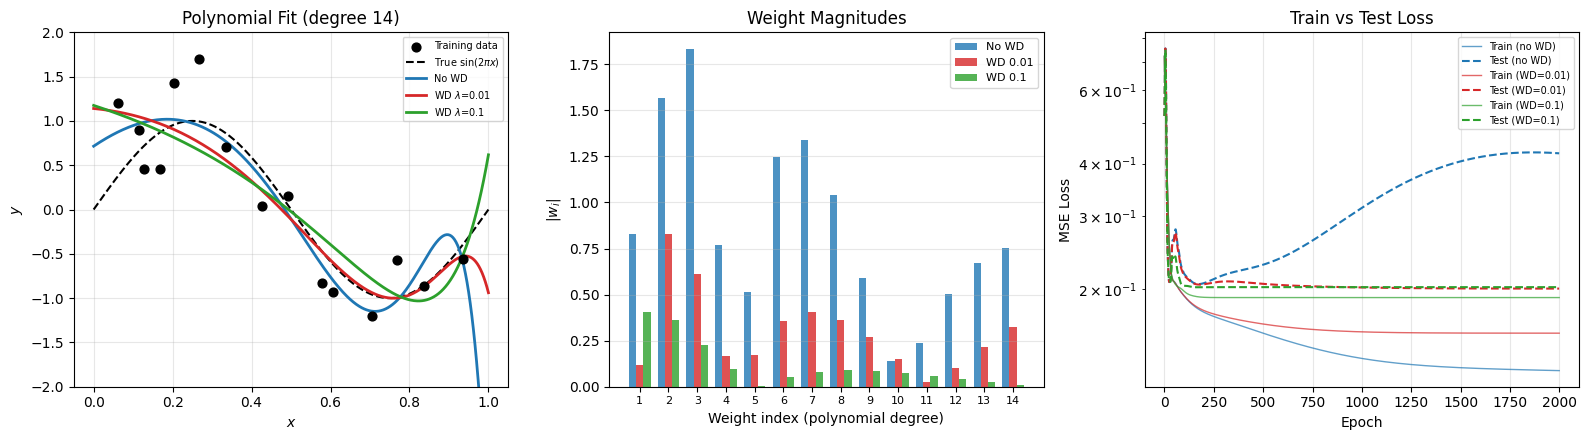

Observations:
  - No WD: polynomial oscillates wildly between data points (overfitting)
  - WD=0.01: oscillations suppressed, test loss much lower
  - WD=0.1: smooth curve close to the true function
  - Weight magnitudes shrink dramatically with regularization


In [46]:
# Dense grid for smooth curve plotting
x_plot = jnp.linspace(0, 1, 500)
X_plot_poly = (poly_features(x_plot, poly_degree) - poly_mean) / poly_std

y_plot_no_wd = linear_model(params_no_wd, X_plot_poly)
y_plot_wd    = linear_model(params_wd, X_plot_poly)
y_plot_wd_s  = linear_model(params_wd_strong, X_plot_poly)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Left: fitted curves ---
ax = axes[0]
ax.scatter(x_train_poly, y_train_poly, c='k', s=40, zorder=5, label='Training data')
ax.plot(x_plot, y_true_fn(x_plot), 'k--', lw=1.5, label='True $\\sin(2\\pi x)$')
ax.plot(x_plot, y_plot_no_wd, 'C0-', lw=2, label='No WD')
ax.plot(x_plot, y_plot_wd, 'C3-', lw=2, label='WD $\\lambda$=0.01')
ax.plot(x_plot, y_plot_wd_s, 'C2-', lw=2, label='WD $\\lambda$=0.1')
ax.set_ylim(-2, 2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Polynomial Fit (degree 14)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

# --- Middle: weight magnitudes ---
ax = axes[1]
idx = np.arange(poly_degree)
width = 0.25
ax.bar(idx - width, np.abs(np.array(params_no_wd['w'])), width, label='No WD', color='C0', alpha=0.8)
ax.bar(idx,         np.abs(np.array(params_wd['w'])),    width, label='WD 0.01', color='C3', alpha=0.8)
ax.bar(idx + width, np.abs(np.array(params_wd_strong['w'])), width, label='WD 0.1', color='C2', alpha=0.8)
ax.set_xlabel('Weight index (polynomial degree)')
ax.set_ylabel('$|w_i|$')
ax.set_title('Weight Magnitudes')
ax.set_xticks(idx)
ax.set_xticklabels([f'{i+1}' for i in idx], fontsize=8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# --- Right: train vs test loss ---
ax = axes[2]
ax.plot(train_no_wd, 'C0-', lw=1, alpha=0.7, label='Train (no WD)')
ax.plot(test_no_wd,  'C0--', lw=1.5, label='Test (no WD)')
ax.plot(train_wd,    'C3-', lw=1, alpha=0.7, label='Train (WD=0.01)')
ax.plot(test_wd,     'C3--', lw=1.5, label='Test (WD=0.01)')
ax.plot(train_wd_s,  'C2-', lw=1, alpha=0.7, label='Train (WD=0.1)')
ax.plot(test_wd_s,   'C2--', lw=1.5, label='Test (WD=0.1)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Train vs Test Loss')
ax.set_yscale('log')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("  - No WD: polynomial oscillates wildly between data points (overfitting)")
print("  - WD=0.01: oscillations suppressed, test loss much lower")
print("  - WD=0.1: smooth curve close to the true function")
print("  - Weight magnitudes shrink dramatically with regularization")

Let's also sweep over a range of weight decay values to find the optimal regularization strength.

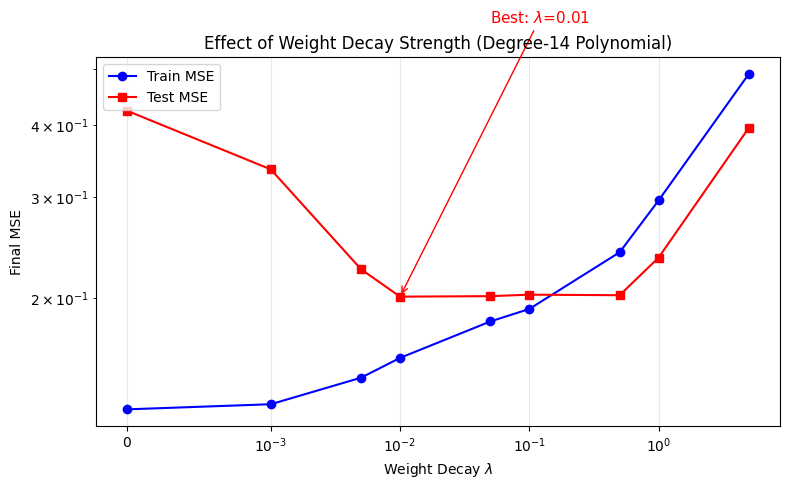

Best weight decay: λ=0.01 (test MSE = 0.2010)
Too little WD → overfitting (wiggly curve); too much WD → underfitting (flat curve)


In [47]:
# Sweep weight decay values
wd_values = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
final_train_losses = []
final_test_losses = []

for wd in wd_values:
    _, tr_hist, te_hist = train_with_optax(
        X_train_poly, y_train_poly, X_test_poly, y_test_poly,
        optax.adam(1e-2), n_epochs=2000, weight_decay=wd
    )
    final_train_losses.append(tr_hist[-1])
    final_test_losses.append(te_hist[-1])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(wd_values, final_train_losses, 'bo-', lw=1.5, label='Train MSE')
ax.plot(wd_values, final_test_losses, 'rs-', lw=1.5, label='Test MSE')
ax.set_xlabel('Weight Decay $\\lambda$')
ax.set_ylabel('Final MSE')
ax.set_title('Effect of Weight Decay Strength (Degree-14 Polynomial)')
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark the best test loss
best_idx = int(np.argmin(final_test_losses))
ax.annotate(f'Best: $\\lambda$={wd_values[best_idx]}',
            xy=(wd_values[best_idx], final_test_losses[best_idx]),
            xytext=(wd_values[best_idx]*5, final_test_losses[best_idx]*3),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red')

plt.tight_layout()
plt.show()

print(f"Best weight decay: λ={wd_values[best_idx]} (test MSE = {final_test_losses[best_idx]:.4f})")
print("Too little WD → overfitting (wiggly curve); too much WD → underfitting (flat curve)")

---
## Summary

| Concept | Key Idea |
|---|---|
| Linear model | $\hat{y} = Xw + b$ — simplest parameterized model |
| MSE loss | $\frac{1}{n}\|Xw+b-y\|^2$ — equivalent to MLE under Gaussian noise |
| Normal equation | Closed-form solution via $(X^\top X)^{-1}X^\top y$ — use `jnp.linalg.solve` |
| Full-batch GD | $w \leftarrow w - \eta \nabla \mathcal{L}$ — smooth convergence, expensive per step |
| Minibatch SGD | Noisy gradient from subset — trade-off between noise and compute |
| Optax | `optax.sgd`, `optax.adam` — standard optimizers, clean API |
| Weight decay | L2 penalty $\lambda\|w\|^2$ — prevents overfitting by shrinking weights |
| Bias-variance trade-off | Too little regularization = overfitting; too much = underfitting |